# Protokollen: hva en modell skal måles mot

Arbeidsverk 2, notebook 02. Bygger på `bostotte_oslo.pdf` fra arbeidsverk 1 og på
notebook 01 i samme mappe.

Notebook 01 svarte på hvor mye informasjon datagrunnlaget inneholder. Denne
notebooken svarer på et annet spørsmål, og det må besvares før den første
maskinlæringsmodellen skrives: **hva skal en modell måles mot, og hvordan.**

Arbeidsverk 1 har en ferdig evalueringsprotokoll — rullerende opprinnelse, 31
opprinnelser, tolv horisonter, MASE og intervallskår — og en modellstige som er
skåret med den. Alt det ligger i R. Skal en Python-modell sammenliknes med den
stigen, må protokollen flyttes over, og flyttingen må kontrolleres. Ellers måler
man to ting med to linjaler og kaller forskjellen et resultat.

Notebooken gjør fire ting:

1. Bygger protokollen i Python, med hver definisjon skrevet ut i kode.
2. Kontrollerer flyttingen mot arbeidsverk 1 på de delene som er deterministiske —
   seksten publiserte tall, reprodusert med den presisjonen de er oppgitt med.
3. Sier hvilke deler som **ikke** lar seg flytte, og hvorfor.
4. Måler en lekkasje i arbeidsverk 1s konformale kalibrering, som til nå bare var
   notert som mistanke.

Ingen modell estimeres her utover de to som har lukket form. Det er de to som gjør
kontrollen mulig.


## 1. Oppsett og datering


In [1]:
import os, subprocess

def git(*a, standard=None):
    try:
        return subprocess.run(["git", *a], capture_output=True, text=True,
                              check=True, cwd=REPO).stdout.strip()
    except Exception:
        return standard

REPO = "/content/bostotte-oslo" if os.path.isdir("/content/bostotte-oslo") else "."
if not os.path.isdir(os.path.join(REPO, "data")):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/Torcode/bostotte-oslo.git",
                    "/content/bostotte-oslo"], check=True)
    REPO = "/content/bostotte-oslo"
elif REPO.startswith("/content"):
    # En klone fra en tidligere oekt kan ligge igjen og vaere gammel.
    git("fetch", "--depth", "1", "origin", "main")
    git("reset", "--hard", "origin/main")

COMMIT  = git("rev-parse", "--short", "HEAD", standard="ukjent")
UTTREKK = "2026-08-04"
print("repo         :", os.path.abspath(REPO))
print("commit       :", COMMIT)
print("uttrekk      :", UTTREKK)


repo         : /home/claude/bostotte-oslo
commit       : f90cd3e
uttrekk      : 2026-08-04


### Sjekksummer, og lenken bakover til notebook 01

Notebook 01 skrev et kjøremanifest med sjekksummene til filene den leste. Cellen
under regner de samme sjekksummene her og henter notebook 01s manifest fra `main`.
Stemmer de ikke overens, arbeider de to notebookene på ulike uttrekk, og ingenting
som sammenliknes på tvers av dem betyr noe.


In [2]:
import hashlib, json
import urllib.request, urllib.error
import pandas as pd

RAW  = os.path.join(REPO, "data/raw/")
FIL  = "husbanken_bostotte_oslo_manedlig.csv"

def sha256(sti, blokk=1 << 20):
    h = hashlib.sha256()
    with open(sti, "rb") as f:
        for b in iter(lambda: f.read(blokk), b""):
            h.update(b)
    return h.hexdigest()

SJEKKSUM = sha256(RAW + FIL)
NB01 = ("https://raw.githubusercontent.com/Torcode/bostotte-oslo/"
        "main/notebooks/bostotte_01_grunnlag.ipynb")

def manifest_fra_notebook(url):
    # Manifestet ligger som lagret utdata i den siste kodecellen i notebook 01.
    nb = json.load(urllib.request.urlopen(url, timeout=30))
    for celle in reversed(nb["cells"]):
        if celle["cell_type"] != "code":
            continue
        if 'MANIFEST["seed"]' not in "".join(celle["source"]):
            continue
        for u in celle.get("outputs", []):
            if u.get("output_type") == "stream":
                return json.loads("".join(u["text"]))
    raise LookupError("fant ikke manifestet i notebook 01")

try:
    M01 = manifest_fra_notebook(NB01)
    LIK_DATA = M01["sjekksum"][FIL] == SJEKKSUM and M01["uttrekk"] == UTTREKK
    LENKE = "samme uttrekk og samme fil" if LIK_DATA else "ULIKT GRUNNLAG"
    assert LIK_DATA, ("notebook 01 leste en annen fil eller et annet uttrekk: "
                      f"{M01['uttrekk']} / {M01['sjekksum'][FIL][:12]} mot "
                      f"{UTTREKK} / {SJEKKSUM[:12]}")
    print(f"Notebook 01 paa main: uttrekk {M01['uttrekk']}, commit {M01['commit']}.")
    print(f"Sjekksum for {FIL}: {LENKE}.")
    print(f"  {SJEKKSUM[:32]}...")
except Exception as e:
    LENKE = f"ikke sjekket ({type(e).__name__})"
    print(f"Naadde ikke notebook 01 paa main ({type(e).__name__}). "
          "Sammenlikninger paa tvers av notebookene er da ikke belagt.")


Notebook 01 paa main: uttrekk 2026-08-04, commit 9b3da3e.
Sjekksum for husbanken_bostotte_oslo_manedlig.csv: samme uttrekk og samme fil.
  5e741e0864bd8d666057b627170ebf0b...


### Harmoni med git

Samme kontroll som i notebook 01, rettet mot denne filen: den henter notebooken fra
`main` og sammenlikner kildeteksten i cellene — kode og prosa, ikke utdata — mot et
avtrykk stemplet inn ved bygging. Cellen holdes utenfor sitt eget avtrykk. Den svarer
på om denne kopien er bygget fra samme revisjon som `main`, ikke på om cellene er
redigert i kopien etterpå.


In [3]:
# harmoni-med-git: denne cellen holdes utenfor sitt eget avtrykk
KILDEAVTRYKK = "4b1ef73db9772a47cbcc8b95a2764003f32ff6a54f74cbf3f75420d1829dfada"
RAATT = ("https://raw.githubusercontent.com/Torcode/bostotte-oslo/"
         "main/notebooks/bostotte_02_protokoll.ipynb")
LOGG  = ("https://api.github.com/repos/Torcode/bostotte-oslo/commits"
         "?path=notebooks/bostotte_02_protokoll.ipynb&per_page=1")

def kildeavtrykk(celler):
    ut = []
    for c in celler:
        kilde = c["source"] if isinstance(c["source"], str) else "".join(c["source"])
        if "harmoni-med-git" not in kilde:
            ut.append(kilde)
    return hashlib.sha256("\n".join(ut).encode("utf-8")).hexdigest()

def hent(url, sekunder=25):
    with urllib.request.urlopen(url, timeout=sekunder) as r:
        return json.load(r)

try:    NAAR = " (sist endret " + hent(LOGG)[0]["commit"]["committer"]["date"][:10] + ")"
except Exception: NAAR = ""

try:
    paa_main = kildeavtrykk(hent(RAATT)["cells"])
    I_HARMONI = paa_main == KILDEAVTRYKK
    MANIFEST_HARMONI = "i harmoni" if I_HARMONI else "avvik mot main"
    if I_HARMONI:
        print(f"I harmoni med main{NAAR}.")
    else:
        print("AVVIK: denne kopien er bygget fra en annen revisjon enn main.")
        print(f"  denne : {KILDEAVTRYKK[:16]}...")
        print(f"  main  : {paa_main[:16]}...{NAAR}")
        print("  merk  : raw.githubusercontent.com mellomlagrer noen minutter, saa"
              " et ferskt push\n          kan vise avvik en kort stund.")
except urllib.error.HTTPError as e:
    if e.code == 404:
        MANIFEST_HARMONI = "finnes ikke paa main"
        print("Notebooken ligger ikke paa main ennaa, saa det finnes ingenting "
              "aa sammenlikne mot.")
    else:
        MANIFEST_HARMONI = f"ikke sjekket (HTTP {e.code})"
        print(f"Kontrollen fikk HTTP {e.code}. Anta at kopien kan vaere utdatert.")
except Exception as e:
    MANIFEST_HARMONI = f"ikke sjekket ({type(e).__name__})"
    print(f"Kontrollen naadde ikke GitHub ({type(e).__name__}). "
          "Da vet vi ikke om kopien er aktuell; anta at den ikke er det.")


Notebooken ligger ikke paa main ennaa, saa det finnes ingenting aa sammenlikne mot.


In [4]:
import platform, importlib
import numpy as np, matplotlib.pyplot as plt
from scipy import stats

SEED = 20260807
np.random.seed(SEED)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

SERIE   = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLEKK, BLEKK_2, DEMPET = "#0b0b0b", "#52514e", "#898781"
RUTE, BASIS = "#e1e0d9", "#c3c2b7"
HARDT = chr(160)

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130, "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.size": 8.5, "axes.titlesize": 9.5, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "text.color": BLEKK, "axes.labelcolor": BLEKK_2,
    "xtick.color": DEMPET, "ytick.color": DEMPET,
    "xtick.labelcolor": BLEKK_2, "ytick.labelcolor": BLEKK_2,
    "axes.edgecolor": BASIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RUTE, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 7.5,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round",
})

def tusen(v, _=None):
    return f"{v:,.0f}".replace(",", HARDT)

MANIFEST = {"commit": COMMIT, "uttrekk": UTTREKK, "python": platform.python_version(),
            "pakker": {}, "sjekksum": {FIL: SJEKKSUM}, "seed": SEED,
            "lenke_notebook01": LENKE}
for p in ["numpy", "pandas", "scipy", "matplotlib"]:
    try:    MANIFEST["pakker"][p] = importlib.import_module(p).__version__
    except ImportError: MANIFEST["pakker"][p] = None
print(json.dumps({k: MANIFEST[k] for k in ["commit", "uttrekk", "python", "pakker"]},
                 indent=2, ensure_ascii=False))


{
  "commit": "f90cd3e",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "scipy": "1.17.1",
    "matplotlib": "3.10.9"
  }
}


## 2. Utvalget, og et vaskeinngrep som må gjengis nøyaktig

Arbeidsverk 1 estimerer på 2017m1 og framover, ikke på hele serien. Før det gjør
det ett inngrep i dataene, kalt V1, og inngrepet er smalere enn det ser ut til.

`ant_husstander_termin` for siste måned i uttrekket står som null. Det er ingen
måling av null mottakere: terminkjøringen for måneden skjer først måneden etter, så
verdien er en **strukturell null** — en rad som finnes fordi kalenderen har rukket
dit, ikke fordi noe er talt. V1 fjerner den raden. Regelen er betinget på at raden
er den siste *og* at verdien er null.

Forskjellen mot en generell nullfiltrering betyr ikke noe for Oslo totalt, der det
bare finnes én null. Den betyr noe for bydelspanelet, der en bydel kan ha en ekte
null i en enkeltmåned uten at raden er en kantrad. Notebook 01 filtrerte på
`ant_husstander_termin > 0`, som er det bredere inngrepet. For Oslo-totalen — som er
det notebook 01 bruker det til — faller de to sammen; cellen under kontrollerer det
framfor å anta det.


In [5]:
raa = pd.read_csv(RAW + FIL)
raa["dato"] = pd.to_datetime(dict(year=raa.aar, month=raa.manedsnr, day=1))
raa = raa.sort_values("dato").reset_index(drop=True)

# V1 slik arbeidsverk 1 definerer det: bare siste rad, og bare hvis den er null.
kant = raa.index[(raa.dato == raa.dato.max()) & (raa.ant_husstander_termin == 0)]
termin = raa.drop(index=kant).reset_index(drop=True)

# Det bredere inngrepet notebook 01 brukte. For Oslo-totalen skal de falle sammen.
bredt = raa[raa.ant_husstander_termin > 0].reset_index(drop=True)
assert termin.dato.equals(bredt.dato), "V1 og nullfiltrering er ikke like for Oslo"

EST_START = pd.Timestamp("2017-01-01")
est = termin[termin.dato >= EST_START].reset_index(drop=True)
M     = est.set_index("dato")["ant_husstander_termin"].astype(float)
LOG_M = np.log(M)
N_EST = len(est)

print(f"uttrekket        : {len(raa)} rader, {raa.dato.min():%Y-%m} - {raa.dato.max():%Y-%m}")
print(f"fjernet av V1    : {len(kant)} rad ({raa.dato.max():%Y-%m}, "
      f"ant_husstander_termin = {raa.ant_husstander_termin.iloc[-1]:.0f})")
print(f"etter V1         : {len(termin)} rader, til {termin.dato.max():%Y-%m}")
print(f"estimeringsutvalg: {N_EST} rader, {est.dato.min():%Y-%m} - {est.dato.max():%Y-%m}")
assert N_EST == 114, "estimeringsutvalget skal ha 114 observasjoner"


uttrekket        : 199 rader, 2010-01 - 2026-07
fjernet av V1    : 1 rad (2026-07, ant_husstander_termin = 0)
etter V1         : 198 rader, til 2026-06
estimeringsutvalg: 114 rader, 2017-01 - 2026-06


114 observasjoner er tallet arbeidsverk 1 oppgir, og `assert`-en holder det fast: et
nytt uttrekk med en måned til gjør at protokollen nedenfor får en opprinnelse mer, og
da skal kjøringen stoppe og be om at tallene i teksten oppdateres, framfor å regne
videre mot et sammenlikningsgrunnlag som ikke lenger gjelder.


## 3. Protokollen

Rullerende opprinnelse med **ekspanderende** vindu. Ved hver opprinnelse trenes det
på alt fram til og med den måneden, og prognostiseres tolv måneder fram. Vinduet
utvides, det ruller ikke: treningen starter alltid i 2017m1.

Tre parametre bestemmer alt: minste treningsvindu på 72 måneder, lengste horisont på
12, og kravet om at hele horisonten skal ligge innenfor utvalget. Sammen gir de 31
opprinnelser og 372 prognosepunkter per modell.


In [6]:
MIN_TRENING, H_MAKS = 72, 12

# Indeksregelen fra arbeidsverk 1, 1-basert paa rad i estimeringsutvalget.
OPPRINNELSER = [est.dato.iloc[i - 1] for i in range(1, N_EST + 1)
                if MIN_TRENING <= i <= N_EST - H_MAKS]
N_OPP  = len(OPPRINNELSER)
N_PKT  = N_OPP * H_MAKS

print(f"minste treningsvindu : {MIN_TRENING} maaneder")
print(f"horisonter           : 1 - {H_MAKS}, alle ved hver opprinnelse")
print(f"opprinnelser         : {N_OPP}, fra {OPPRINNELSER[0]:%Y-%m} "
      f"til {OPPRINNELSER[-1]:%Y-%m}")
print(f"prognosepunkter      : {N_OPP} x {H_MAKS} = {N_PKT} per modell")
print(f"evalueringsvindu     : {OPPRINNELSER[0] + pd.DateOffset(months=1):%Y-%m} - "
      f"{OPPRINNELSER[-1] + pd.DateOffset(months=H_MAKS):%Y-%m}")

assert (N_OPP, N_PKT) == (31, 372)
assert OPPRINNELSER[0] == pd.Timestamp("2022-12-01")
assert OPPRINNELSER[-1] == pd.Timestamp("2025-06-01")


minste treningsvindu : 72 maaneder
horisonter           : 1 - 12, alle ved hver opprinnelse
opprinnelser         : 31, fra 2022-12 til 2025-06
prognosepunkter      : 31 x 12 = 372 per modell
evalueringsvindu     : 2023-01 - 2026-06


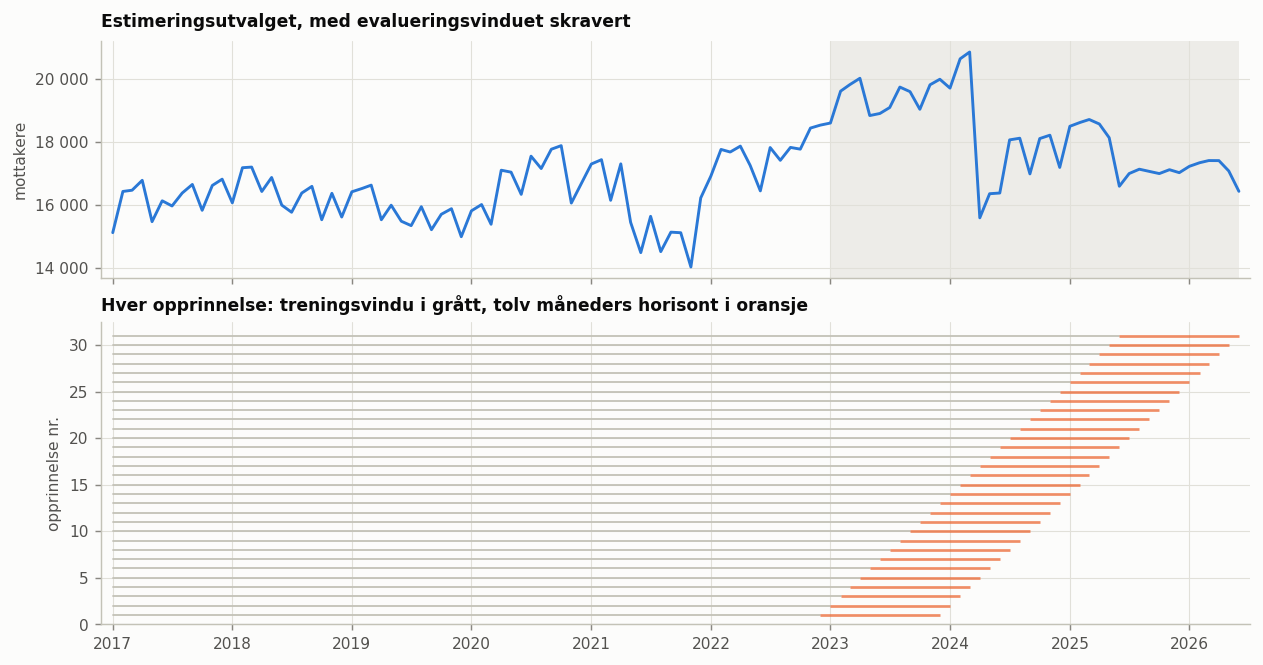

In [7]:
fig, akser = plt.subplots(2, 1, figsize=(9.6, 5.0), sharex=True, layout="constrained",
                          gridspec_kw={"height_ratios": [1.25, 1.6]})

ax = akser[0]
ax.plot(M.index, M.values, color=SERIE[0])
ax.axvspan(OPPRINNELSER[0] + pd.DateOffset(months=1),
           OPPRINNELSER[-1] + pd.DateOffset(months=H_MAKS),
           color=RUTE, alpha=0.55, lw=0, zorder=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(tusen))
ax.set_ylabel("mottakere")
ax.set_title("Estimeringsutvalget, med evalueringsvinduet skravert")
ax.margins(x=0.01)

ax = akser[1]
for i, t0 in enumerate(OPPRINNELSER, start=1):
    ax.plot([t0, t0 + pd.DateOffset(months=H_MAKS)], [i, i],
            color=SERIE[1], lw=1.5, alpha=0.75, solid_capstyle="butt")
    ax.plot([EST_START, t0], [i, i], color=BASIS, lw=1.0, zorder=1)
ax.set_ylabel("opprinnelse nr.")
ax.set_xlabel("")
ax.set_title("Hver opprinnelse: treningsvindu i grått, tolv måneders horisont i oransje",
             pad=6)
ax.set_ylim(0, N_OPP + 1.5)
ax.margins(x=0.01)
plt.show()


Nederste rute er hele designet i én figur. Hver linje er én opprinnelse. Det grå
strekket til venstre er det modellen har sett, det oransje til høyre er de tolv
månedene den skal treffe. At de grå strekkene alle starter samme sted, er det
ekspanderende vinduet; at de oransje overlapper hverandre, er grunnen til at
prognosefeilene ikke er uavhengige, og til at testene i avsnitt 4 må korrigere for
autokorrelasjon.

Overlappet er også grunnen til at det ikke er 372 uavhengige observasjoner. Én
måned i 2024 blir truffet av opptil tolv ulike opprinnelser, og de tolv feilene deler
det samme utfallet. Et samlet MASE-tall over 372 punkter er derfor et gjennomsnitt
med langt færre frihetsgrader enn tallet antyder.


## 4. Målene

Fire mål, og hvert av dem har et valg i seg som avgjør hva tallet betyr.

**MASE.** Absoluttfeilen skalert med en nevner. Nevneren er sesongnaiv feil med lag
12, regnet **på nivåskala** og **i treningsvinduet ved hver opprinnelse**. Begge
presiseringene har konsekvenser: en nevner regnet på hele serien ville brukt framtid,
og en nevner på logskala ville gitt et annet tall. Nevneren vokser når serien blir
mer volatil, så MASE er ikke sammenliknbar på tvers av perioder uten videre.

**Intervallskår.** Bredden pluss en straff for observasjoner utenfor, med vekt
2/α = 10 ved nominelt 80 %. Målet belønner smale intervaller, men bare til det punkt
der de begynner å bomme. Det er derfor det brukes ved siden av dekning framfor i
stedet for.

**Dekning.** Andelen av utfallene som faller innenfor. Sier ingenting om bredden, og
kan alltid drives til 100 % ved å gjøre intervallet ubrukelig vidt.

**Diebold–Mariano og Clark–West.** Om forskjellen mellom to modellers kvadrerte feil
er større enn støyen. Testen kjøres per horisont, slik at prognosefeilene som
sammenliknes ikke overlapper hverandre, og langvariansen bruker et rektangulært
vindu med $L = h - 1$ lag. Clark–West brukes der den ene modellen er nøstet i den
andre; uten den justeringen er DM skjev mot den større modellen, fordi den estimerer
parametre som er null under nullhypotesen.

Funksjonen under følger arbeidsverk 1s implementasjon ledd for ledd, inkludert
Harvey-korreksjonen og at autokovariansene deles på $n$ for alle lag. Den er likevel
**ikke** kontrollert mot et publisert tall: arbeidsverk 1 rapporterer bare par som
involverer M6, og M6 er ikke reprodusert her. Formelen er altså gjengitt, ikke
verifisert, og det står i kildekolonnen når den brukes.


In [8]:
Z80, Z95 = stats.norm.ppf(0.90), stats.norm.ppf(0.975)
ALFA = 0.20

def mase_nevner(t0, sesong=12):
    # Sesongnaiv MAE paa nivaaskala, kun i treningsvinduet.
    x = M.loc[:t0].values
    return np.abs(x[sesong:] - x[:-sesong]).mean()

NEVNER = {t0: mase_nevner(t0) for t0 in OPPRINNELSER}

def intervallskaar(sant, nedre, ovre, alfa=ALFA):
    return ((ovre - nedre)
            + (2/alfa) * (nedre - sant) * (sant < nedre)
            + (2/alfa) * (sant - ovre) * (sant > ovre))

def skaar(R):
    R = R.copy()
    R["pred"] = np.exp(R.mu)                       # median, ren eksponensiering
    R["e"]    = R.sant - R.pred
    R["mase"] = R.e.abs() / R.opprinnelse.map(NEVNER)
    R["logfeil"] = np.log(R.sant) - R.mu
    for niva, z in [(80, Z80), (95, Z95)]:
        R[f"l{niva}"] = np.exp(R.mu - z*R.sd)
        R[f"u{niva}"] = np.exp(R.mu + z*R.sd)
        R[f"dekk{niva}"] = (R.sant >= R[f"l{niva}"]) & (R.sant <= R[f"u{niva}"])
    R["ws80"] = intervallskaar(R.sant, R.l80, R.u80)
    return R

def samlet(R):
    g = R.groupby("modell")
    return pd.DataFrame({
        "MASE": g.mase.mean(),
        "RMSE": np.sqrt(g.apply(lambda x: (x.e**2).mean())),
        "dekning 80": 100*g.dekk80.mean(),
        "dekning 95": 100*g.dekk95.mean(),
        "intervallskaar": g.ws80.mean()}).sort_values("MASE")

# Diebold-Mariano med Harvey-korreksjon; Clark-West naar a er noestet i b.
# Positiv verdi favoriserer b. Tapet er kvadrert feil paa nivaaskala.
def dm_harvey(R, a, b, h, noestet=False):
    x = (R[R.modell.isin([a, b]) & (R.h == h)]
         .pivot(index="opprinnelse", columns="modell", values="e").dropna())
    e1, e2 = x[a].values, x[b].values
    n = len(e1)
    d = e1**2 - (e2**2 - (e1 - e2)**2) if noestet else e1**2 - e2**2
    L  = h - 1
    dc = d - d.mean()
    # Autokovarians med nevner n for alle lag, som R sin acf(type="covariance").
    gamma = np.array([(dc[:n - k] * dc[k:]).sum() / n for k in range(L + 1)])
    v = (gamma[0] + 2*gamma[1:].sum()) / n
    if not np.isfinite(v) or v <= 0:
        return np.nan
    return (d.mean() / np.sqrt(v)) * np.sqrt((n + 1 - 2*h + h*(h - 1)/n) / n)

print(f"z80 = {Z80:.6f}   z95 = {Z95:.6f}   straffevekt 2/alfa = {2/ALFA:.0f}")
print(f"MASE-nevner ved foerste opprinnelse : {NEVNER[OPPRINNELSER[0]]:8.1f}")
print(f"MASE-nevner ved siste opprinnelse   : {NEVNER[OPPRINNELSER[-1]]:8.1f}")


z80 = 1.281552   z95 = 1.959964   straffevekt 2/alfa = 10
MASE-nevner ved foerste opprinnelse :   1216.5
MASE-nevner ved siste opprinnelse   :   1420.4


Nevneren vokser 17 prosent mellom første og siste opprinnelse, fra 1 216 til 1 420
husstander. Det er ikke en feil: avviklingen i april 2024 legger seg inn i
treningsvinduet og gjør den sesongnaive referansen dårligere. Følgen er at samme
absolutte feil gir lavere MASE ved en sen opprinnelse enn ved en tidlig. MASE-tall
fra ulike opprinnelser kan altså ikke uten videre legges ved siden av hverandre, og
det samlede snittet vekter implisitt de sene opprinnelsene ned.


## 5. Kontrollen: to modeller med lukket form

Her kommer prøven på om protokollen faktisk er den samme. To av modellene i
arbeidsverk 1s stige har lukket form og krever ingen estimering av orden:

- **M0, naiv.** Prognosen er siste observerte verdi, uansett horisont. På logskala
  er variansen $\hat\sigma^2 h$.
- **M1, sesongnaiv.** Prognosen er verdien tolv måneder før målmåneden. Variansen er
  $\hat\sigma^2\lfloor 1 + (h-1)/12 \rfloor$.

Begge er implementert her fra bunnen. Punktprognosene er helt deterministiske, så
MASE og RMSE for dem er en ren test av at opprinnelser, horisonter, nevner,
tilbaketransformasjon og sammenstilling mot fasit er like. Intervallmålene tester i
tillegg at variansestimatet er det samme.


In [9]:
def bygg_referanse():
    rad = []
    for t0 in OPPRINNELSER:
        tr = LOG_M.loc[:t0]
        # Residualvarians uten frihetsgradskorreksjon, slik fable regner den.
        sd0 = np.sqrt((np.diff(tr.values) ** 2).mean())
        sd1 = np.sqrt(((tr.values[12:] - tr.values[:-12]) ** 2).mean())
        for h in range(1, H_MAKS + 1):
            maal = t0 + pd.DateOffset(months=h)
            kilde = maal - pd.DateOffset(months=12 * int(np.ceil(h / 12)))
            rad += [
                dict(modell="M0", opprinnelse=t0, h=h, dato=maal, sant=M.loc[maal],
                     mu=tr.iloc[-1],       sd=sd0 * np.sqrt(h)),
                dict(modell="M1", opprinnelse=t0, h=h, dato=maal, sant=M.loc[maal],
                     mu=LOG_M.loc[kilde],  sd=sd1 * np.sqrt(1 + (h - 1) // 12)),
            ]
    return pd.DataFrame(rad)

R = skaar(bygg_referanse())
assert len(R) == 2 * N_PKT, "referansen har ikke 372 punkter per modell"

# Ved h = 12 henter sesongnaiv fra t0+12-12 = t0, altsaa der naiv henter sin.
# De to modellene er da den samme prognosen, og det skal vises i tallene.
h12 = R[R.h == 12].pivot(index="opprinnelse", columns="modell", values="mu")
assert np.allclose(h12.M0, h12.M1), "M0 og M1 er ikke like ved h = 12"
samlet(R).round(3)


,MASE,RMSE,dekning 80,dekning 95,intervallskaar
modell,,,,,
M0,1.003,1698.202,91.398,97.581,7082.266
M1,1.228,1843.901,76.882,96.774,6124.534


### Mot arbeidsverk 1

Tabellen over er regnet her, i Python, fra rådataene. Tabellen under er hentet fra
tabell 17 i `bostotte_oslo.pdf`, som er rendret fra R. De to skal være like.


In [10]:
DEL1 = pd.DataFrame(
    [["M0", 1.003, 1698, 91, 98, 7082],
     ["M1", 1.228, 1844, 77, 97, 6125]],
    columns=["modell", "MASE", "RMSE", "dekning 80", "dekning 95", "intervallskaar"]
).set_index("modell")

her = samlet(R)

# Avrundet til den presisjonen arbeidsverk 1 oppgir, ikke lenger.
SIFRE = {"MASE": 3, "RMSE": 0, "dekning 80": 0, "dekning 95": 0, "intervallskaar": 0}
avrundet = pd.DataFrame({k: her[k].round(n) for k, n in SIFRE.items()})
avvik = (avrundet - DEL1[list(SIFRE)]).abs()
assert (avvik.values == 0).all(), f"avvik mot arbeidsverk 1:\n{avvik}"

sml = pd.DataFrame([
    {"stoerrelse": f"{m}  {k}", "arbeidsverk 1": DEL1.loc[m, k],
     "her, uavrundet": round(float(her.loc[m, k]), 3),
     "her, avrundet": avrundet.loc[m, k], "avvik": avvik.loc[m, k]}
    for m in ["M0", "M1"] for k in SIFRE]).set_index("stoerrelse")
sml.index.name = None

print(f"{avrundet.size} tall sammenliknet, {int((avvik.values == 0).sum())} like, "
      f"{int((avvik.values != 0).sum())} ulike.\n")
sml


10 tall sammenliknet, 10 like, 0 ulike.



,arbeidsverk 1,"her, uavrundet","her, avrundet",avvik
M0 MASE,1.003,1.003,1.003,0.0
M0 RMSE,1698.000,1698.202,1698.000,0.0
M0 dekning 80,91.000,91.398,91.000,0.0
M0 dekning 95,98.000,97.581,98.000,0.0
M0 intervallskaar,7082.000,7082.266,7082.000,0.0
M1 MASE,1.228,1.228,1.228,0.0
M1 RMSE,1844.000,1843.901,1844.000,0.0
M1 dekning 80,77.000,76.882,77.000,0.0
M1 dekning 95,97.000,96.774,97.000,0.0
M1 intervallskaar,6125.000,6124.534,6125.000,0.0


Ti tall, oppgitt med tre til fire siffer, alle like. Det er sterkere enn det ser ut,
fordi tallene er følsomme for forskjellige ting. RMSE på 1 698 husstander ville
flyttet seg om en eneste opprinnelse var forskjøvet én måned. MASE ville flyttet seg
om nevneren var regnet på hele serien i stedet for på treningsvinduet, eller på
logskala i stedet for på nivå. Intervallskåren på 7 082 ville flyttet seg om
variansestimatet hadde hatt en frihetsgradskorreksjon.

Det siste er verdt å merke seg, siden det ikke står skrevet noe sted: `assert`-en
holder bare når residualvariansen regnes uten korreksjon, altså som rent
gjennomsnitt av kvadrerte residualer. Med `n − 1` blir intervallskåren for M0 7 107
og for M1 6 121. Konvensjonen er altså ikke antatt her, den er **avlest av at den
ene av dem treffer**.


### En kontroll til: kalibreringen av kalenderregressoren

Arbeidsverk 1 bruker en kalenderregressor bygget på antall meldekortutbetalinger i
måneden. Griddet har én fri parameter, fasen, og den er kalibrert på den nasjonale
serien for husstander med midlertidige trygdeytelser. Kalibreringen er deterministisk
og lar seg derfor også flyttes og kontrolleres.


In [11]:
NASJ_BG = "husbanken_bostotte_nasjonalt_brukergruppe_manedlig.csv"
BEH = "Husstander med midlertidige trygdeytelser"

g = pd.read_csv(RAW + NASJ_BG)
g["dato"] = pd.to_datetime(dict(year=g.aar, month=g.manedsnr, day=1))
b = (g[(g.brukergruppe == BEH) & (g.ant_husstander_termin > 0)]
     .sort_values("dato").reset_index(drop=True))

# Sentrert 2x12-glatting, og det relative avviket fra den.
vekt = np.r_[0.5, np.ones(11), 0.5] / 12
glatt = np.convolve(b.ant_husstander_termin.astype(float).values, vekt, mode="same")
glatt[:6] = glatt[-6:] = np.nan
b["z"] = b.ant_husstander_termin / glatt - 1

kal = b[b.z.notna() & (b.dato >= "2017-01-01") & (b.dato <= "2024-12-01")
        & ~((b.dato >= "2020-03-01") & (b.dato <= "2020-12-01"))]

def u_av_fase(fase, fra=pd.Timestamp("2010-01-01"), til=pd.Timestamp("2027-12-31")):
    anker = pd.Timestamp("2014-01-06") + pd.Timedelta(days=fase)
    start = anker - pd.Timedelta(days=14 * int(np.ceil((anker - fra).days / 14)))
    dager = pd.date_range(start, til, freq="14D")
    return (pd.Series(dager[dager >= fra]).dt.to_period("M").dt.to_timestamp()
            .value_counts().sort_index().rename("u"))

rad = []
for fase in range(14):
    j = kal.join(u_av_fase(fase), on="dato")
    z3, z2 = j.z[j.u == 3].values, j.z[j.u == 2].values
    gap = z3.mean() - z2.mean()
    t = gap / np.sqrt(z3.var(ddof=1)/len(z3) + z2.var(ddof=1)/len(z2))
    rad.append((fase, 100*gap, t))

faser = pd.DataFrame(rad, columns=["fase", "gap %", "t"]).sort_values("t")
FASE_VALGT = int(faser.fase.iloc[0])
tre = faser.head(3).round(1).set_index("fase")
assert tre.index.tolist() == [0, 7, 1], "andre faser vinner enn i arbeidsverk 1"
assert tre["gap %"].tolist() == [-16.1, -12.7, -10.0]
assert tre["t"].tolist() == [-10.3, -6.8, -3.8]
print(f"valgt fase: {FASE_VALGT}   (arbeidsverk 1, tabell 12: fase 0)\n")
tre


valgt fase: 0   (arbeidsverk 1, tabell 12: fase 0)



,gap %,t
fase,,
0,-16.1,-10.3
7,-12.7,-6.8
1,-10.0,-3.8


Tre rader til, seks tall, alle like — og fasen som velges er den samme. Til sammen
er seksten publiserte tall fra arbeidsverk 1 reprodusert med uavhengig kode i et
annet språk.

Det som dermed er kontrollert er hele skåringsapparatet: hvilke opprinnelser som
inngår, hvilke horisonter, hvordan nevneren regnes, hvordan log tilbaketransformeres,
hvordan intervaller bygges, hvordan dekning telles, hvordan intervallskåren straffer,
og at kalenderregressoren blir den samme. Det er dette maskineriet notebook 03 og
utover måler mot.


## 6. Hva som ikke lar seg flytte

De seks andre trinnene i stigen — ETS, SARIMA og de tre RegARIMA-variantene — er
ikke reimplementert her, og det er et valg som skal begrunnes framfor å passere
stille.

Modellene er ikke gitt med fast orden. `ARIMA()` i R-pakken `fable` velger
$(p,d,q)(P,D,Q)_{12}$ ved et stegvis søk på AICc, med differensiering bestemt av
KPSS og av et sesongstyrkemål, og valget gjentas ved hver av de 31 opprinnelsene.
Python har ingen implementasjon som er dokumentert å gjøre det samme søket med de
samme grensene. En «M3» skrevet her ville derfor vært en annen modell med samme
navn, og et avvik mellom den og arbeidsverk 1 ville ikke kunnet tilskrives noe.

Skillet er verdt å holde fast ved, fordi det er generelt: **en protokoll kan flyttes
mellom språk og kontrolleres tallmessig, en tilpasningsalgoritme kan det som regel
ikke.** Det er derfor kontrollen over gjelder skåringen og ikke modellene, og det er
også derfor notebook 03 og utover sammenlikner sine egne modeller mot de publiserte
tallene i tabell 17, ikke mot en Python-kopi av dem.

De publiserte tallene står her, som referanse for det som kommer:


In [12]:
STIGE = pd.DataFrame(
    [["M0", "naiv",                   1.003, 1698, 91, 98, 7082],
     ["M1", "sesongnaiv",             1.228, 1844, 77, 97, 6125],
     ["M2", "ETS",                    0.931, 1565, 83, 92, 5760],
     ["M3", "SARIMA",                 1.131, 1944, 73, 85, 8031],
     ["M4", "RegARIMA + k",           1.063, 1823, 74, 84, 7367],
     ["M5", "RegARIMA + X",           0.867, 1391, 52, 76, 5840],
     ["M6", "RegARIMA + X + k",       0.967, 1525, 42, 65, 7213],
     ["M7", "M6 + paalagt bidrag",    0.838, 1322, 48, 71, 5791]],
    columns=["id", "modell", "MASE", "RMSE", "dekning 80", "dekning 95",
             "intervallskaar"]).set_index("id")
STIGE["kilde"] = ["kontrollert her", "kontrollert her"] + ["arbeidsverk 1"]*6
STIGE.sort_values("MASE")


,modell,MASE,RMSE,dekning 80,dekning 95,intervallskaar,kilde
id,,,,,,,
M7,M6 + paalagt bidrag,0.838,1322,48,71,5791,arbeidsverk 1
M5,RegARIMA + X,0.867,1391,52,76,5840,arbeidsverk 1
M2,ETS,0.931,1565,83,92,5760,arbeidsverk 1
M6,RegARIMA + X + k,0.967,1525,42,65,7213,arbeidsverk 1
M0,naiv,1.003,1698,91,98,7082,kontrollert her
M4,RegARIMA + k,1.063,1823,74,84,7367,arbeidsverk 1
M3,SARIMA,1.131,1944,73,85,8031,arbeidsverk 1
M1,sesongnaiv,1.228,1844,77,97,6125,kontrollert her


Kolonnen `kilde` er ikke pynt. De to øverste radene er regnet i denne notebooken og
stemmer med det publiserte; de seks andre er avskrift. Et senere resultat som slår
M5 eller M7 må derfor stå mot et tall som ikke er uavhengig kontrollert her, og det
skal stå i teksten når det skjer.

Legg samtidig merke til hva raden for M0 sier. Den naive modellen — siste observerte
verdi, uansett horisont — har MASE 1,003 og slår både SARIMA og den sesongnaive.
Det er ikke et tegn på at modellene er dårlige, men på hva slags serie dette er: en
beholdning der de fleste husstandene blir værende fra måned til måned, slik notebook
01 viste. Nivået i dag er derfor et sterkt anslag på nivået om et halvt år, og enhver
modell som skal være nyttig, må slå den terskelen.


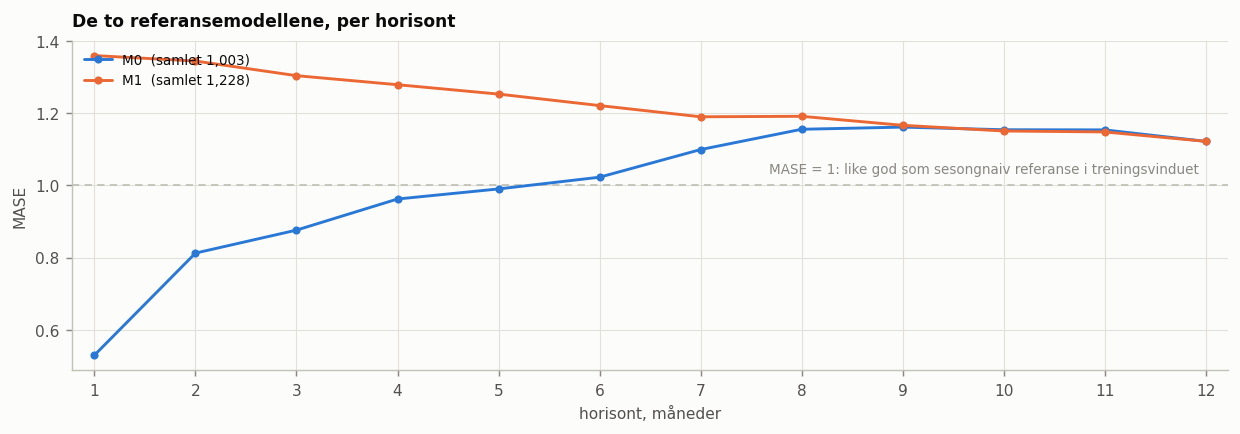

In [13]:
ph = (R.groupby(["modell", "h"]).mase.mean().unstack(0))

fig, ax = plt.subplots(figsize=(9.6, 3.4))
for (navn, serie), farge in zip(ph.items(), SERIE):
    ax.plot(ph.index, serie, color=farge, marker="o", ms=3.5,
            label=f"{navn}  (samlet {her.MASE[navn]:.3f})".replace(".", ","))
ax.axhline(1.0, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.annotate("MASE = 1: like god som sesongnaiv referanse i treningsvinduet",
            xy=(H_MAKS, 1.0), xycoords=("data", "data"), xytext=(-4, 5),
            textcoords="offset points", ha="right", va="bottom",
            fontsize=7.5, color=DEMPET)
ax.set_xticks(range(1, H_MAKS + 1))
ax.set_xlabel("horisont, måneder")
ax.set_ylabel("MASE")
ax.set_title("De to referansemodellene, per horisont")
ax.legend(loc="upper left")
ax.margins(x=0.02)
fig.tight_layout(); plt.show()


Figuren sier tre ting om hva som er en reell terskel.

Den naive stiger med horisonten, fra 0,53 ved h = 1 til 1,12 ved h = 12, altså en
faktor 2,1. En tilfeldig gang med uavhengige tilvekster ville gitt en faktor
$\sqrt{12} \approx 3{,}5$. Feilen vokser dermed klart saktere enn ren vandring
tilsier — serien trekkes tilbake mot et nivå framfor å drive fritt. Dette er én
observasjon på tvers av horisonter og ikke en test, men retningen er entydig.

De to kurvene møtes ved h = 12, og det er ikke tilfeldig. Den sesongnaive prognosen
for måned $t_0 + 12$ hentes fra $t_0 + 12 - 12 = t_0$, som er nøyaktig der den naive
henter sin. Ved tolv måneders horisont **er** de to modellene samme prognose, og
cellen over har en `assert` på at tallene viser det. Ved h = 12 finnes det derfor
bare én referanse, ikke to.

Avstanden mellom dem er størst ved h = 1: 0,53 mot 1,36. En modell som slår den
sesongnaive på korte horisonter, har slått den svakeste referansen der den er
svakest. Terskelen som gjelder hele veien, er den naive.


In [14]:
dm = pd.DataFrame({
    "DM(M1 mot M0)": [dm_harvey(R, "M1", "M0", h) for h in range(1, H_MAKS + 1)]
}, index=pd.Index(range(1, H_MAKS + 1), name="h")).round(2)

# Ved h = 12 er de to modellene samme prognose, saa tapsdifferansen er identisk null
# og teststatistikken kan ikke defineres. At den er NaN er kontrollen paa at
# implementasjonen ikke finner signal der det ikke finnes noe.
assert np.isnan(dm.iloc[-1, 0]), "teststatistikken er definert der feilene er like"
print("Positiv verdi favoriserer M0. Ensidig kritisk verdi ved 5 %: 1,64.")
print("h = 12 gir NaN fordi de to modellene da er samme prognose.\n")
dm.T


Positiv verdi favoriserer M0. Ensidig kritisk verdi ved 5 %: 1,64.
h = 12 gir NaN fordi de to modellene da er samme prognose.



h,1,2,3,4,5,6,7,8,9,10,11,12
DM(M1 mot M0),4.23,1.65,0.71,0.51,0.5,0.33,0.11,0.06,-0.71,-0.51,0.22,NaN


Bare ved h = 1 er forskjellen entydig større enn støyen: 4,23 mot en ensidig kritisk
verdi på 1,64. Ved h = 2 ligger den så vidt over, og fra h = 3 lar den seg ikke skille
fra null. Figuren viste et tydelig gap på korte horisonter; testen sier at gapet
tåler vekt ved h = 1 og knapt ved h = 2. Med 31 opprinnelser og en asymptotisk
teststatistikk er det omtrent så mye som er å hente her.

Raden slutter i NaN, og det er testen på implementasjonen. Ved h = 12 er de to
modellene samme prognose, tapsdifferansen er identisk null, og en teststatistikk kan
ikke dannes. En implementasjon som likevel hadde returnert et tall der, ville funnet
signal i null.


## 7. En lekkasje i den konformale kalibreringen

Arbeidsverk 1 etterkalibrerer intervallene konformalt: for horisont $h$ og
opprinnelse $\tau$ bygges intervallet av den empiriske kvantilen til $|e_h|$ fra
tidligere opprinnelser. Rapporten oppgir at kalibreringen løfter dekningen for
hovedspesifikasjonen fra 45 til 73 prosent.

«Tidligere opprinnelse» er implementert som *opprinnelse tidligere i rekkefølgen*.
Men en prognosefeil er ikke kjent ved opprinnelsen — den er kjent når målmåneden er
observert. Feilen fra opprinnelse $t_j$ på horisont $h$ realiseres i $t_j + h$. Ved
opprinnelse $t_i$ er den derfor bare tilgjengelig hvis

$$t_j + h \le t_i.$$

Arbeidsverk 1 krever bare $t_j < t_i$. For $h = 1$ er de to kravene like. For
$h = 12$ er de det ikke i det hele tatt: kalibreringen bruker da feil som først blir
kjent opptil elleve måneder etter at intervallet skulle vært stilt.

Cellen under regner begge skjemaene på de samme prognosene, med samme oppvarmingskrav
på minst tre kalibreringspunkter. Forskjellen mellom dem er lekkasjen, isolert.


In [15]:
def konformal(R, modell, tidsgyldig, niva=0.80, min_kal=3):
    ut = []
    for h, g in R[R.modell == modell].groupby("h"):
        g = g.sort_values("opprinnelse").reset_index(drop=True)
        realisert = g.opprinnelse + pd.DateOffset(months=int(h))
        for i in range(len(g)):
            ti = g.opprinnelse.iloc[i]
            # Forskjellen mellom skjemaene er denne ene linjen.
            kal = g[realisert <= ti] if tidsgyldig else g.iloc[:i]
            if len(kal) < min_kal:
                continue
            q = np.quantile(np.abs(kal.logfeil.values), niva, method="linear")
            mu, sant = g.mu.iloc[i], g.sant.iloc[i]
            ut.append(dict(h=h, opprinnelse=ti, n_kal=len(kal), q=q,
                           dekk=bool(np.exp(mu - q) <= sant <= np.exp(mu + q))))
    return pd.DataFrame(ut)

A = konformal(R, "M0", tidsgyldig=False)   # slik arbeidsverk 1 gjoer det
B = konformal(R, "M0", tidsgyldig=True)    # bare feil som var realisert

# Kontrollen: ved h = 1 er de to kravene identiske, saa skjemaene maa falle sammen.
a1 = A[A.h == 1].reset_index(drop=True); b1 = B[B.h == 1].reset_index(drop=True)
assert a1.equals(b1), "skjemaene skiller lag ved h = 1, der de ikke kan gjoere det"

felles = A.merge(B, on=["h", "opprinnelse"], suffixes=("_a", "_b"))
BARE_A = int(( felles.dekk_a & ~felles.dekk_b).sum())
BARE_B = int((~felles.dekk_a &  felles.dekk_b).sum())
FORHOLD = felles.q_a / felles.q_b

print(f"arbeidsverk 1s skjema : {len(A):3d} punkter, dekning {100*A.dekk.mean():.1f} %")
print(f"bare realiserte feil  : {len(B):3d} punkter, dekning {100*B.dekk.mean():.1f} %")
print(f"paa de {len(felles)} felles punktene : "
      f"{100*felles.dekk_a.mean():.1f} % mot {100*felles.dekk_b.mean():.1f} % "
      f"(nominelt {100*0.80:.0f} %)\n")
print(f"dekket bare av arbeidsverk 1s skjema : {BARE_A}")
print(f"dekket bare av det tidsgyldige       : {BARE_B}")
print(f"kvantilforhold q_A/q_B: median {FORHOLD.median():.2f}, "
      f"snitt {FORHOLD.mean():.2f}, stoerst {FORHOLD.max():.1f}")
print(f"  q_B er stoerst i {int((FORHOLD < 1).sum())} av {len(FORHOLD)} punkter, "
      f"q_A i {int((FORHOLD > 1).sum())}")
print(f"\nKontroll ved h = 1: {len(a1)} punkter, identiske i begge skjemaer.")


arbeidsverk 1s skjema : 336 punkter, dekning 74.4 %
bare realiserte feil  : 270 punkter, dekning 67.4 %
paa de 270 felles punktene : 78.5 % mot 67.4 % (nominelt 80 %)

dekket bare av arbeidsverk 1s skjema : 32
dekket bare av det tidsgyldige       : 2
kvantilforhold q_A/q_B: median 1.00, snitt 1.28, stoerst 5.8
  q_B er stoerst i 135 av 270 punkter, q_A i 107

Kontroll ved h = 1: 28 punkter, identiske i begge skjemaer.


A = arbeidsverk 1s skjema, B = bare realiserte feil

    kal.pkt A  punkter A  dekning A  kal.pkt B  punkter B  dekning B
h                                                                   
1          30         28       60.7         30         28       60.7
2          30         28       71.4         29         27       70.4
3          30         28       82.1         28         26       73.1
4          30         28       71.4         27         25       72.0
5          30         28       67.9         26         24       58.3
6          30         28       67.9         25         23       56.5
7          30         28       75.0         24         22       63.6
8          30         28       78.6         23         21       61.9
9          30         28       78.6         22         20       70.0
10         30         28       78.6         21         19       68.4
11         30         28       82.1         20         18       77.8
12         30         28       78.6         19    

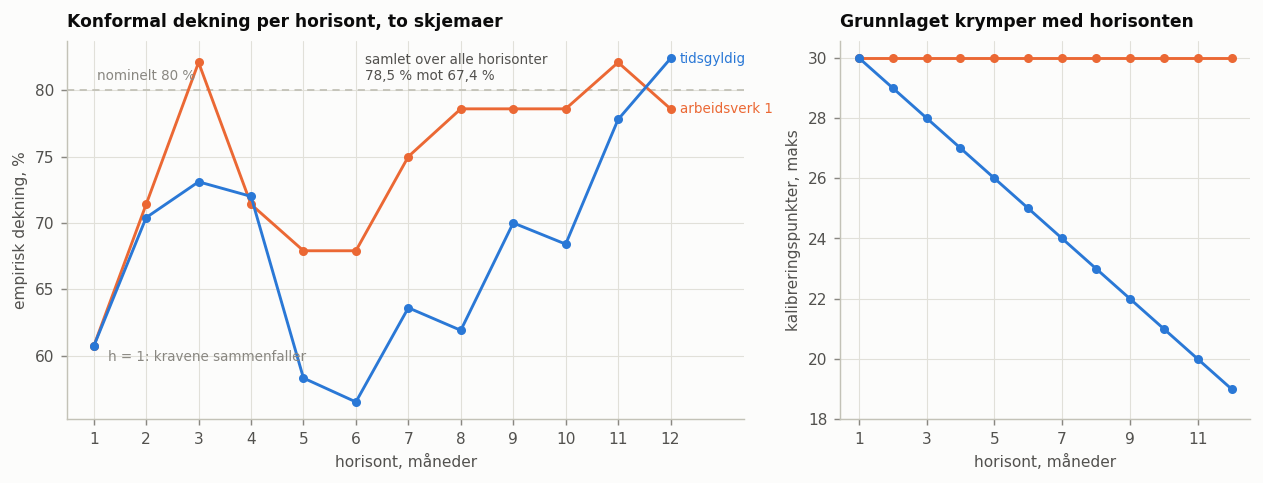

In [16]:
tab = pd.DataFrame({
    "kal.pkt A": A.groupby("h").n_kal.max(),
    "punkter A": A.groupby("h").size(),
    "dekning A": 100*A.groupby("h").dekk.mean(),
    "kal.pkt B": B.groupby("h").n_kal.max(),
    "punkter B": B.groupby("h").size(),
    "dekning B": 100*B.groupby("h").dekk.mean()}).round(1)
print("A = arbeidsverk 1s skjema, B = bare realiserte feil\n")
print(tab.to_string())

fig, akser = plt.subplots(1, 2, figsize=(9.6, 3.6), layout="constrained",
                          gridspec_kw={"width_ratios": [1.65, 1]})

ax = akser[0]
linjer = [("dekning A", SERIE[1], "arbeidsverk 1"),
          ("dekning B", SERIE[0], "tidsgyldig")]
for kol, farge, etikett in linjer:
    ax.plot(tab.index, tab[kol], color=farge, marker="o", ms=4)
    ax.annotate(etikett, xy=(H_MAKS, tab[kol].iloc[-1]), xytext=(5, 0),
                textcoords="offset points", ha="left", va="center",
                fontsize=7.5, color=farge, annotation_clip=False)
ax.axhline(80, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.annotate("nominelt 80 %", xy=(1, 80), xytext=(2, 4), textcoords="offset points",
            ha="left", va="bottom", fontsize=7.5, color=DEMPET)
ax.annotate("h = 1: kravene sammenfaller", xy=(1, tab["dekning A"].iloc[0]),
            xytext=(8, -2), textcoords="offset points", ha="left", va="top",
            fontsize=7.5, color=DEMPET)
ax.annotate(("samlet over alle horisonter\n"
             f"{100*felles.dekk_a.mean():.1f} % mot "
             f"{100*felles.dekk_b.mean():.1f} %").replace(".", ","),
            xy=(0.44, 0.97), xycoords="axes fraction", ha="left", va="top",
            fontsize=7.5, color=BLEKK_2)
ax.set_xticks(range(1, H_MAKS + 1))
ax.set_xlim(0.5, H_MAKS + 1.4)
ax.set_xlabel("horisont, måneder"); ax.set_ylabel("empirisk dekning, %")
ax.set_title("Konformal dekning per horisont, to skjemaer")

ax = akser[1]
for kol, farge, _ in [("kal.pkt A", SERIE[1], ""), ("kal.pkt B", SERIE[0], "")]:
    ax.plot(tab.index, tab[kol], color=farge, marker="o", ms=4)
ax.set_xticks(range(1, H_MAKS + 1, 2))
ax.set_yticks(range(18, 32, 2))
ax.set_xlabel("horisont, måneder"); ax.set_ylabel("kalibreringspunkter, maks")
ax.set_title("Grunnlaget krymper med horisonten")
plt.show()


Venstre rute skal leses med måtehold. Hvert punkt bygger på mellom 17 og 28
prognoser, så ett enkelt utfall flytter kurven fire til seks prosentpoeng, og formen
er støy like mye som mønster. To ting i figuren er likevel ikke støy.

Det ene er sammenfallet ved h = 1. Det er ingen observasjon, det er en `assert` i
cellen over: der er de to kravene identiske, så hadde kurvene startet ulikt, ville
forskjellen skyldtes noe annet enn lekkasjen, og kjøringen hadde stoppet.

Det andre er det samlede tallet. På de 270 punktene begge skjemaene skårer, dekker
arbeidsverk 1s versjon 78,5 prosent mot nominelle 80, det tidsgyldige 67,4. Og
retningen er entydig punkt for punkt: 32 punkter dekkes bare av det lekkende
skjemaet, 2 bare av det tidsgyldige. Kalibreringen ser altså ut til å treffe fordi
den får se feil som ikke fantes da intervallet skulle vært stilt.

Høyre rute forklarer hvorfor problemet ikke lar seg fikse ved å bytte krav og gå
videre. Det lekkende skjemaet har 30 kalibreringspunkter ved enhver horisont. Det
tidsgyldige har 30 ved h = 1 og 19 ved h = 12, og skårer 28 punkter mot 17. Ved
lange horisonter skal en 80-prosents kvantil altså estimeres på under tjue tall.
Riktig regnet er kalibreringen svakest nettopp der den trengs mest — og det er ikke
en svakhet ved skjemaet, men ved datamengden: tolv måneders horisont krever tolv
måneders venting før hver eneste kalibreringsobservasjon finnes.

Én ting til, som avgjør om lekkasjen lar seg korrigere bort. Kvantilene fra de to
skjemaene er ikke systematisk forskjellige: medianen av forholdet $q_A/q_B$ er 1,00,
og det tidsgyldige gir den største kvantilen i 135 av 270 punkter. Snittet av
forholdet er derimot 1,28. Lekkasjen virker altså ikke som en jevn utvidelse av alle
intervaller, men som en kraftig utvidelse av noen få — nemlig de der framtiden som
lekker inn, inneholder et brudd. En fast korreksjonsfaktor på bredden ville derfor
ikke gjenopprette noe; kalibreringssettet må avgrenses.

Alt dette er regnet på M0, den ene modellen der prognosene kan reproduseres eksakt.
Lekkasjen er en egenskap ved **skjemaet** og ikke ved modellen, så mekanismen gjelder
alle åtte trinnene i stigen. Hvor stort utslaget blir for hvert av dem er ikke målt
her, og påstanden strekkes ikke lenger enn til M0.


## 8. Hva notebook 03 arver

Protokollen er nå definert i kode og kontrollert mot arbeidsverk 1 der den lot seg
kontrollere. Notebook 03 og utover bruker den slik:

- `OPPRINNELSER`, `H_MAKS` og `NEVNER` som de er. En modell som skårer på et annet
  sett opprinnelser, skårer ikke mot tabellen i avsnitt 6.
- `skaar()` og `samlet()` som eneste vei fra prognose til tall.
- Tabellen `STIGE` som referanse, med kildekolonnen intakt.
- Det tidsgyldige konformale skjemaet, ikke arbeidsverk 1s.

Fire ting står åpne og skal ikke framstilles som løst:

1. **Funksjonene bor i en notebook.** De hører hjemme i en pakke `bostotte/` som
   både R-siden og Python-siden kan kalle. Så lenge de er duplisert per notebook,
   er det ingen mekanisme som hindrer at de gliv fra hverandre — bare kontrollen i
   avsnitt 5, som må gjentas.
2. **Lekkasjen er målt, ikke rettet i arbeidsverk 1.** Rapportens tall 45 → 73
   prosent står fortsatt i PDF-en.
3. **Seks av åtte trinn er avskrift.** Se avsnitt 6.
4. **Overlappet er ikke priset inn.** 372 punkter er ikke 372 uavhengige
   observasjoner, og ingen av tallene her korrigerer for det. Testene i avsnitt 4
   gjør det per horisont; det samlede snittet gjør det ikke.


### Kjøremanifest


In [17]:
MANIFEST["protokoll"] = {
    "est_start": f"{EST_START:%Y-%m}", "n_est": int(N_EST),
    "min_trening": MIN_TRENING, "h_maks": H_MAKS,
    "opprinnelser": int(N_OPP), "prognosepunkter": int(N_PKT),
    "forste_opprinnelse": f"{OPPRINNELSER[0]:%Y-%m}",
    "siste_opprinnelse": f"{OPPRINNELSER[-1]:%Y-%m}",
    "fase_kalender": FASE_VALGT,
}
MANIFEST["kontroll_mot_arbeidsverk1"] = {
    "tall_sammenliknet": int(avrundet.size) + 6,
    "avvik": int((avvik.values != 0).sum()),
    "modeller": ["M0", "M1"],
    "variansestimat": "uten frihetsgradskorreksjon (avlest, ikke antatt)",
}
MANIFEST["konformal"] = {
    "skjema_arbeidsverk1_dekning": round(float(100*felles.dekk_a.mean()), 1),
    "skjema_tidsgyldig_dekning": round(float(100*felles.dekk_b.mean()), 1),
    "felles_punkter": int(len(felles)),
    "kontroll_h1": "identiske skjemaer, assert",
}
MANIFEST["kontroller"] = {
    "v1_lik_nullfiltrering_oslo": "ok",
    "harmoni_med_main": MANIFEST_HARMONI,
    "lenke_notebook01": LENKE,
}
print(json.dumps(MANIFEST, indent=2, ensure_ascii=False))


{
  "commit": "f90cd3e",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "scipy": "1.17.1",
    "matplotlib": "3.10.9"
  },
  "sjekksum": {
    "husbanken_bostotte_oslo_manedlig.csv": "5e741e0864bd8d666057b627170ebf0b47229ea846f0ed98717cc5bc590600d6"
  },
  "seed": 20260807,
  "lenke_notebook01": "samme uttrekk og samme fil",
  "protokoll": {
    "est_start": "2017-01",
    "n_est": 114,
    "min_trening": 72,
    "h_maks": 12,
    "opprinnelser": 31,
    "prognosepunkter": 372,
    "forste_opprinnelse": "2022-12",
    "siste_opprinnelse": "2025-06",
    "fase_kalender": 0
  },
  "kontroll_mot_arbeidsverk1": {
    "tall_sammenliknet": 16,
    "avvik": 0,
    "modeller": [
      "M0",
      "M1"
    ],
    "variansestimat": "uten frihetsgradskorreksjon (avlest, ikke antatt)"
  },
  "konformal": {
    "skjema_arbeidsverk1_dekning": 78.5,
    "skjema_tidsgyldig_dekning": 67.4,
    "felles_punkter": 270,
    "kontroll_h1": "i